# ROUGE and Summarization


## First, let's finish up the group work from last time

I asked you to find a `text-classification` model and the dataset that was used to train it.

https://huggingface.co/models?pipeline_tag=text-classification&sort=trending

Let's use those instead of `SamLowe/roberta-base-go_emotions` and `go_emotions`

**Group Discussion:** What needs to change in this code to make it work?

In [1]:
from transformers import pipeline
from datasets import load_dataset
from accelerate import Accelerator
from sklearn.metrics import accuracy_score

device = Accelerator().device

print("Currently using device:",str(device).upper())

dataset = load_dataset("go_emotions")
classifier = pipeline("sentiment-analysis", model="SamLowe/roberta-base-go_emotions", device=device)

results = classifier(dataset["test"]["text"][0:1000])

predicted_labels = []
actual_labels = []

for idx in range(1000):
    predicted_labels.append(results[idx]["label"])
    actual_label_numeric = dataset["test"]["labels"][idx][0]
    actual_labels.append( dataset["test"].features["labels"].feature.int2str( actual_label_numeric ) )

print("Accuracy:",accuracy_score(actual_labels,predicted_labels) )

Currently using device: MPS


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy: 0.593


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Accuracy: 0.135


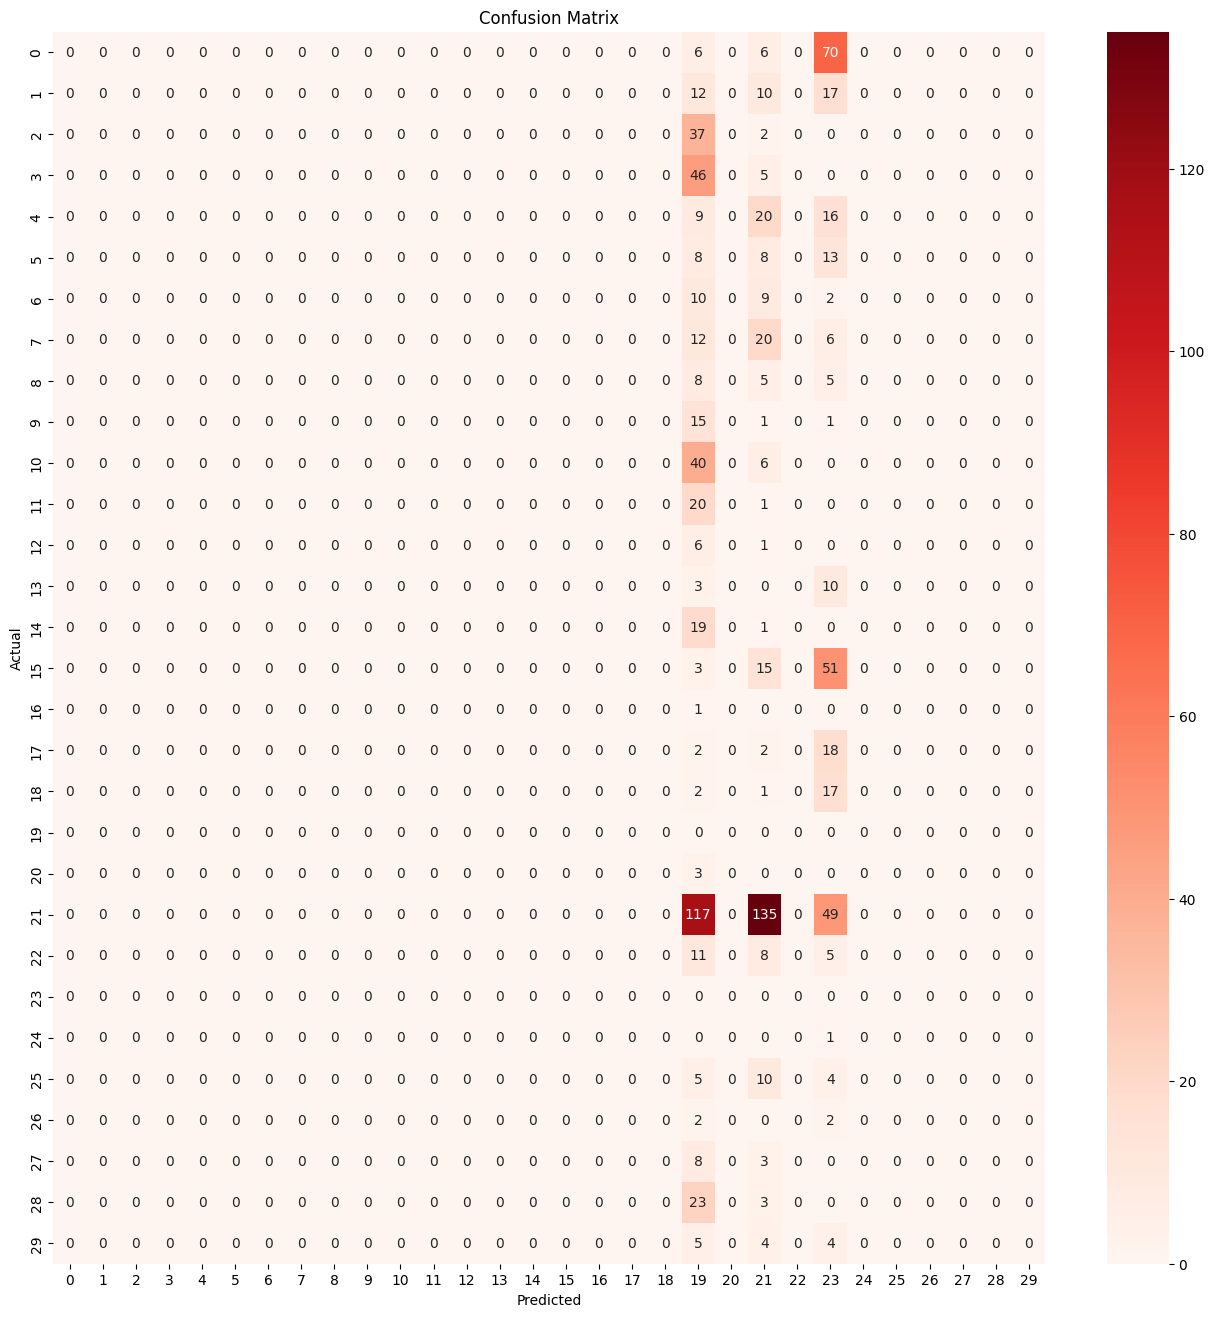

In [2]:
#copied for testing

# using model from HuggingFace called "cardiffnlp/twitter-roberta-base-sentiment-latest"
# dataset from HuggingFace called "go_emotions" 

#link for model: https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest
#link for dataset: https://huggingface.co/datasets/go_emotions

#Model trained on ~124M tweets from January 2018 to December 2021, and finetuned for sentiment analysis with the TweetEval benchmark





from transformers import pipeline
from datasets import load_dataset
from accelerate import Accelerator
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = Accelerator().device

dataset = load_dataset("go_emotions")
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest", device=device)

results = classifier(dataset["test"]["text"][0:1000])

predicted_labels = []
actual_labels = []

for idx in range(1000):
    predicted_labels.append(results[idx]["label"])
    actual_label_numeric = dataset["test"]["labels"][idx][0]
    actual_labels.append( dataset["test"].features["labels"].feature.int2str( actual_label_numeric ) )

print("Accuracy:",accuracy_score(actual_labels,predicted_labels) )

# Creating a confusion matrix

cm = confusion_matrix(actual_labels, predicted_labels)

plt.figure(figsize=(16, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Group Activity:** Spend the next 10 minutes getting this to work with the new model and test data.

## Next Tuesday: First Demo Day!

Reminder: you will present a demo to your group on whatever you've done for the first fortnight
* Show off one **Applied Exploration** that you finished
    - finished outside of class, polished it up, included answers to all requested questions and any other notes of interest
* If you have completed any **Creative Synthesis** items - show those off
    - if you're doing this, spend less/very-little time on your Applied Exploration demo, but you should still have it for your portfolio
    - check the [syllabus](https://github.com/ericmanley/S26-CS195NLP/blob/main/F0_0_Syllabus.ipynb) for options
* If you didn't do any *Creative Synthesis* or *Applied Exploration*, show a **Core Practice**

We'll talk more about portfolio format later

## References

*Two minutes NLP — Learn the ROUGE metric* by examples by Fabio Chiusano: https://medium.com/nlplanet/two-minutes-nlp-learn-the-rouge-metric-by-examples-f179cc285499

Google's implementation of rouge_score: https://github.com/google-research/google-research/tree/master/rouge

Hugging Face's wrapper for Google's implementation: https://huggingface.co/spaces/evaluate-metric/rouge *(NB: this page seems to be down, but it's still linked from many places in the Hugging Face documentation, so I don't know when it will become accessible)*

Hugging Face Task Guide on Summarization: https://huggingface.co/docs/transformers/tasks/summarization


## Future Warning: Installing necessary modules

Hugging Face officially released version 5 of their `transformers` library last week.

See https://huggingface.co/blog/transformers-v5 and https://github.com/huggingface/transformers/blob/main/MIGRATION_GUIDE_V5.md

Unfortunately, the documentation (i.e., in their LLM course we're referencing) is still using Transformers 4, so we're going to stick with that for now.

Today we're going to use the `summarization` pipeline which has been depreciated (you'll still be able to do it in version 5, it'll just be a different pipeline.

**Colab users:** You will need to run this to install version 4 and then restart your session for it to take effect.

In [3]:
import sys
!{sys.executable} -m pip install "transformers<5" datasets evaluate rouge_score

/bin/bash: /Users/sagar/School/Drake: No such file or directory


In [4]:
import transformers
transformers.__version__

'5.1.0'

## Sequence-to-Sequence Models

NLP models that take one sequence as input and produce another sequence as output are called **seq2seq**, **text-to-text**, or **text generation**
* summarization
* translation
* conversation

**A Challenge:** unlike classification, there's no way to tell for sure whether the prediction is right!

**Partial Solutions:**
* Qualitative metrics - humans can describe how closely they match
* ROUGE Metrics: statistics that measure similarities between two sequences.
* Task-specific metrics like BLEU (Bilingual Evaluation Understudy) for translation



## Getting started with ROUGE

**ROUGE:** Recall-Oriented Understudy for Gisting Evaluation

Suppose we have a **reference** sequence, which is one known possible *correct* sequence
* E.g., a translation or a summarization that a trustworthy human has produced

**Example reference:** "A broody hen sat in a nesting box all day."

**Example machine-generated prediction:** "A hen sat in every nesting box that long sunny day."



In [5]:
import evaluate

rouge = evaluate.load("rouge")

predicted_sentence = "A broody hen sat in a nesting box all day"
reference_sentence = "A hen sat in every nesting box that long sunny day"

rouge.compute(predictions=[predicted_sentence],references=[reference_sentence])

{'rouge1': np.float64(0.6666666666666666),
 'rouge2': np.float64(0.3157894736842105),
 'rougeL': np.float64(0.6666666666666666),
 'rougeLsum': np.float64(0.6666666666666666)}

## Understanding ROUGE-1 and ROUGE-2

These tell you how often words or sequences of words match in the prediction and reference data.

`rouge1` - overlap of individual words (1-grams) between prediction and reference

`rouge2` - overlap of *bigrams* (2-grams, pairs of consecutive words)

Both of these are given in terms of their F1 score. Remember, F1 is a balance of *precision* and *recall*, specifically $$F1 = 2 * (Precision * Recall) / (Precision + Recall)$$

### in this context...

**Precision:** Given all the n-grams in the *predictions*, how many are also present in the *reference*?

**Recall:** Given all the n-grams in the *reference*, how many are also present in the *prediction*?

### ROUGE-1 example

**Reference:** A broody hen sat in a nesting box all day. (10 words)

**Prediction:** A hen sat in every nesting box that long sunny day. (11 words)

**Overlapping words:** a, hen, sat, in, nesting, box, day (7 words)

**Precision:** of the 11 words in the prediction, 7 of them are also in the reference, so $7/11 \approx 0.64$

**Recall:** of the 10 words in the reference, 7 of them are also present in the prediction (first "a" has match, second doesn't), so $7/10 = 0.7$

**F1 score:** $2*(0.64*0.7)/(0.64+0.7) \approx 0.67$


### ROUGE-2 example

**Reference:** A broody hen sat in a nesting box all day. (9 bigrams)

**Prediction:** A hen sat in every nesting box that long sunny day. (10 bigrams)

**Overlapping bigrams:** (hen sat), (sat in), (nesting box) (3 bigrams)

**Precision:** of the 10 bigrams in the prediction, 3 of them are also in the reference, so $3/10 = 0.3$

**Recall:** of the 9 bigrams in the reference, 3 of them are also present in the prediction, so $3/9 \approx 0.33$

**F1 score:** $2*(0.3*0.33)/(0.3+0.33) \approx 0.31$

## Understanding ROUGE-L and ROUGE-Lsum

`rougeL` - the *longest common subsequence* between the prediction and reference. The subsequence must be in *order* but not nececssarily *consecutive*

**Reference:** **A** broody **hen sat in** a **nesting box** all **day**. (10 words)

**Prediction:** **A hen sat in** every **nesting box** that long sunny **day**. (11 words)

**Longest Common Subsequence:** 7 words

**Precision:** 7 words of 11 in the prediction, 0.64

**Recall:** 7 of 10 words in the reference, 0.7

**F1 score:** $2*(0.64*0.7)/(0.64+0.7) \approx 0.67$

`rougeLsum` - do `rougeL` for each newline/sentence and aggregate the results


## Group Activity

Given the following Reference and Prediction, calculate the ROUGE-1, ROUGE-2, and ROUGE-L scores.

**Reference:** the study found that regular exercise improves mental health and reduces stress

**Prediction:** the study shows exercise improves mental health and lowers stress



In [6]:
import evaluate

rouge = evaluate.load("rouge")

predicted_sentence = "the study found that regular exercise improves mental health and reduces stress"
reference_sentence = "the study shows exercise improves mental health and lowers stress"

rouge.compute(predictions=[predicted_sentence],references=[reference_sentence])

{'rouge1': np.float64(0.7272727272727272),
 'rouge2': np.float64(0.5),
 'rougeL': np.float64(0.7272727272727272),
 'rougeLsum': np.float64(0.7272727272727272)}

## Summarization in Hugging Face

Hugging Face hosts many summarization models. Here's one called BART (https://huggingface.co/facebook/bart-large-cnn) that was trained on CNN/Daily Mail news articles (https://huggingface.co/datasets/abisee/cnn_dailymail) which include **reference** summaries written by the authors of the original article.

We'll try it out on a Times-Delphic article I found here: https://timesdelphic.com/83979/news/drake-events-focus-on-the-link-between-cancer-and-water-quality-in-iowa/

In [7]:
times_delphic_story = """Drake University hosted the Iowa Nature Summit in the Olmsted Center on Nov. 19 and 20 to discuss Iowa environmental preservation, issues and policies.

The water conditions in Iowa continued to be a buzzing topic less than a week after Drake hosted the Water Quality Solutions Town Hall on Nov. 15, a follow-up to a Central Iowa Source Water Resource Assessment report.

The water quality tracking data in the report showed that potentially harmful nitrates were found in the Des Moines and Raccoon Rivers.

Adam Shriver, director of wellness and nutrition policy at the Harkin Institute, was one of five panelists who discussed the connection between public health and the state of Iowa’s nature due to human impact.

During his time on the podium, Shriver focused on the potential connection between water quality and the growing cancer rates, especially amongst younger age groups in Iowa.

“Iowa having the number two cancer rate in the country is something that I think should be troubling to all of us, both because of how devastating cancer is and also because many young people are choosing to leave the state partly because of concerns about this topic,” Shriver said.

Although the population decline amongst young people is concerning, Shriver noted a growing concern from Iowan citizens, recalling the Central Iowa Source Water Resource Assessment event hosted by the Harkin Institute that gathered over 600 in-person attendees and thousands online.

“I’ve got grandchildren [in Iowa] thinking about the future and them seeing the decline of quality in the state, how much it can be hurt,” said Iowa Citizens for Community Improvement member Tim Goldman.

Shriver said that it’s important to be knowledgeable and raise awareness about the issue of water quality. By supporting change-making organizations such as the Harkin Institute, Iowa Environmental Council and Iowa Citizens for Community Improvements, Iowans can aid in affecting state policies and laws.

“Ultimately, the reason we have high nitrates in our waters and why Iowa applies 53 million pounds of pesticides every year have to do with the policies that are in place … I’m a believer that the way change happens is through organized money or through organized people,” Shriver said. “People advocating for change are often at a disadvantage when it comes to money, so we need to go all out for organizing people.”

With the upcoming 2026 elections, Shriver said that keeping environmental issues affecting Iowan communities in mind when voting is one of the ways for change and bettering of Iowan health.

Shriver furthermore expressed the importance of the growing cancer rates to be a topic of discussion among Iowa leaders, and the importance of opening conversations regarding agricultural practices that may be the root of the issue.

Like Shriver, John Norris, a former Polk County administrator who commissioned the CISWRA report, marked the importance of Iowan values in guiding future policies. Norris advised attendees of the Water Quality Solutions Town Hall to vote in upcoming elections with valuing clean water in mind.

“We have to start anchoring our politics in values,” Norris said.

Through continued research regarding the correlation between water quality and cancer, the Harkin Institute will continue holding events in collaboration with various organizations to keep not only the community but the state of Iowa informed.

The presentation “Cancer in Polk County” will be hosted at Sheslow Auditorium along with a virtual Zoom option on Tuesday, Jan. 13, from 5-7 p.m. In the days following, the “Environmental Risk Factors and Cancer” report will be released in conjunction with the Iowa Environmental Council to continue the conversation.
"""

In [11]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = "Sachin21112004/distilbart-news-summarizer"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

article = times_delphic_story

inputs = tokenizer(article, return_tensors="pt", max_length=1024, truncation=True)
summary_ids = model.generate(
    inputs["input_ids"],
    max_length=5000,
    min_length=1000,
    no_repeat_ngram_size=3,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

print(tokenizer.decode(summary_ids[0], skip_special_tokens=True))


Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

 The event was a follow-up to a Central Iowa Source Water Quality Solutions Town Hall on Nov. 15 . Shriver said the number of young people leaving the state because of the issue is a concern for their health . The event will continue to be held in conjunction with the Iowa Citizens for Community Improvement event on Tuesday, Jan. 13, at 5-7 p.m. Shriver urged people to vote in the upcoming elections to keep the issue of clean water in mind . The meeting will also be held at the University of Iowa’s International Water Quality Council on Jan. 27-28. “Cancer in Polk County” will be hosted at 5 p.30 p.29 p.31 p.45 p.05 p.15 p.28 p.35 p.55 p.38 p.39 p.59 p.40 p.57 p.37 p.49 p.51 p.33 p.53 p.58 p.47 p.50 p.54 p.52 p.36 p.44 p.07 p.32 p.48 p.56 p.08 p.79 p.78 p.84 p.7. P.29p.38p.45p. The event is the first time the conference has been held in Iowa. The conference is the second time the event has been hosted in the state has been in the United States has been scheduled to be hosted in Iowa ha

## Output was truncated 
## I marked down output for better visibility
## model_id = "Sachin21112004/distilbart-news-summarizer"




 The event was a follow-up to a Central Iowa Source Water Quality Solutions Town Hall on Nov. 15 . Shriver said the number of young people leaving the state because of the issue is a concern for their health . The event will continue to be held in conjunction with the Iowa Citizens for Community Improvement event on Tuesday, Jan. 13, at 5-7 p.m. Shriver urged people to vote in the upcoming elections to keep the issue of clean water in mind . The meeting will also be held at the University of Iowa’s International Water Quality Council on Jan. 27-28. “Cancer in Polk County” will be hosted at 5 p.30 p.29 p.31 p.45 p.05 p.15 p.28 p.35 p.55 p.38 p.39 p.59 p.40 p.57 p.37 p.49 p.51 p.33 p.53 p.58 p.47 p.50 p.54 p.52 p.36 p.44 p.07 p.32 p.48 p.56 p.08 p.79 p.78 p.84 p.7. P.29p.38p.45p. The event is the first time the conference has been held in Iowa. The conference is the second time the event has been hosted in the state has been in the United States has been scheduled to be hosted in Iowa has been a year. The first time it has been the last time it was held in the U.29 is the conference was the first meeting was the last year. It was the third time it had been hosted by the event was in the first event was the second event was hosted by a conference in the conference. The meeting was a meeting was held by the first was the fourth time the participants had been in a year after it was in Washington, Washington, D.Maryland, D-Maryland County, Dauntauntaunt, Duntaunt, Maryland County. The last time the state’ve been in Washington. It’ll be the first to discuss the first. It has been concluded. It is the third. It had been the first of the year’t been a meeting. The following week, the conference’. The participants were in Washington’S. Maryland, Maryand. Maryand, Dattatt. She’m Maryand’d. Mary’and the last. She said, “We’re not. We’r. Maryan. Maryanna, Maryan,” she said. ‘I’bout” was a member of the “council.” She said: “She’n” – Maryand: ‘She” is the ‘sustustust’ was the mother of the second. She was the daughter of the mother’ – She said she’esustust. She also said that she was the wife of the first, she said she was “a member of a family. She is the author of the.intustust, she was a mother of a daughter of a mother. She has said she had a daughter. She told her to be a friend of the two. She had a friend. She asked for a daughter’ said she said that her mother of her husband. She described her mother. The mother of two children’ sustust for the two’said. She explained that she had to be the mother.’ She was a daughter, her mother, her daughter, and she said’she was a sister of the three. She gave her to her husband’ed for a mother, and her husband, and said she.‘tried to her daughter of two.“. The two” for the first and she”. The ‘“‘must for a friend�. The author. She and her daughter” said. She added to her mother was the author’negan’egan to be back for the second, said to be “’l.must. Maryann. She-mout. She. was a ‘mout’ for the.matt” and she was back to the back of the back’, ‘tough to the bottom of the pack’ of the family’’�s back to her friends’ and said, she‘n‘eghgh’ to get back in the back. She declined to give her back to me” to the rest of the Daunt’to-back’ she said to her family” . She said to have her back . She was back for her.

In [13]:
len(times_delphic_story) #let's check how long this string is - some might be too long for the model

3744

## Individual work: Let's try it on a different summarization dataset

The *BillSum* dataset contains the text of legislative bills and their summaries from both the US Federal and California State legislatures.

See more here: FiscalNote/billsum

This dataset has `train`, `test`, and `ca_test` splits. We can load just one of them - let's try the `ca-test` which is the smaller test set.


In [14]:
from datasets import load_dataset

billsum = load_dataset("billsum", split="ca_test")

## Let's explore the dataset

What does it look like when printed/displayed?

In [15]:
print(billsum)

Dataset({
    features: ['text', 'summary', 'title'],
    num_rows: 1237
})


What does one of the items look like?

In [16]:
#billsum[0]

Let's get a summary of the first bill using the news-article summarizer. We're going to limit the summarizer to the first 4000 characters because of limits this model sometimes runs into on certain hardware. You can try it without the `[:4000]` and see how it goes (it worked fine on my Mac).

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_id = "Sachin21112004/distilbart-news-summarizer"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

article = billsum[0]["text"]

inputs = tokenizer(article, return_tensors="pt", max_length=1024, truncation=True)
summary_ids = model.generate(
    inputs["input_ids"],
    max_length=5000,
    min_length=1000,
    no_repeat_ngram_size=3,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

print(tokenizer.decode(summary_ids[0], skip_special_tokens=True))

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

 Since 1899 congressionally chartered veterans’ organizations have provided a valuable service to our nation’s returning service members . These organizations help preserve the memories and incidents of the great hostilities fought by our nation, and preserve and strengthen comradeship among members . The U.S. Internal Revenue Service created a special tax exemption for these organizations under Section 501(c)(19) of the Internal Revenue Code . These properties act as a safe haven where veterans of all ages and their families can gather together to find camaraderie and fellowship, share stories, and seek support from people who understand their unique experiences . The exemption has resulted in an onerous tax burden on California veteran service organizations posts or halls, hinders the posts’ ability to provide facilities for veterans, and threatens the economic viability of many local organizations. The State Board of Equalization's interpretation of the tax exemption reflects a lack

# Output
 
 
 Since 1899 congressionally chartered veterans’ organizations have provided a valuable service to our nation’s returning service members . These organizations help preserve the memories and incidents of the great hostilities fought by our nation, and preserve and strengthen comradeship among members . The U.S. Internal Revenue Service created a special tax exemption for these organizations under Section 501(c)(19) of the Internal Revenue Code . These properties act as a safe haven where veterans of all ages and their families can gather together to find camaraderie and fellowship, share stories, and seek support from people who understand their unique experiences . The exemption has resulted in an onerous tax burden on California veteran service organizations posts or halls, hinders the posts’ ability to provide facilities for veterans, and threatens the economic viability of many local organizations. The State Board of Equalization's interpretation of the tax exemption reflects a lack of understanding of the purpose and programs of our veteran community. The tax exemption is detrimental to the good of the service organizations, the author says. The state Board of E.C.A. C.J. Liu writes. Liu says. Liu wrote. Liu. Liu: “The tax exemption has been a burden on the State. Liu is a burden. Liu’. Liu has written. The author of Liu: The state of Liu, the state’ll be a burden for the state. Liu and the author of the author. The reader of the article. The writer. The article, the reader of Liu. The law, the writer of the law. The letter, the editor of the letter to the reader. The editor of this article. We’ve written. It’d like to clarify that the state of the reader’t like to see the state to clarify. We have been the author to clarify the state and reader of our state. We are happy to clarify our state to state that we’re happy to state. The public. We like to state our view. We want to clarify this. We believe that we are happy. We need to state the reader to state to comment. We do not object to the author’m happy to make clear. We wish to state this.” The state. It is happy to share our view of the public. The opinion. We. appreciate this. California. The . state. California’�s interpretation of this statement. The. Liu, however, has a problem. It has been the editor. The Legislature. We apologize. We think it is a mistake. We understand it. The people of the State of California. We can’egan to express our concern. We hope to clarify it. It would like to make it clear that it is clear that the . author. It does not believe it.’espect it. There are no longer need to explain this. It was a problem, and it is not a problem”. The legislature. The bill. The authors. A problem. The governor. It. For the benefit of the . public. It will be a problem . The author. There. of the. government. The ... author. Invent. Of the public’a problem. There’S. A. New. California, The . author, the . article. For a public. For. the author, The author,’r. The Committee. The Council. For The. author. To clarify. The (author. For . the . writer. For more. The “vail. For your comment. The comment. for the . letter. For (for the purposes of the (vail for the reason. ‘vile. of . the. exception. of. the . government. For For the reason, the. author�. ’s opinion. For not. The… Liu. (’negan to explain. �. “‘tow back to the . viscisciscare. I’viscare” – Liu”” Back Back Back To Back To The Back Back to The Back To Me Back To You Back To Your Back To To The Front Back Back Home. Back To Front Back To Home Back Back Off The Front To Back Back In The Back Off To Back Off Off Back Off Back Back On Back Back Together, Back Back Front Back Home, Back Off Now. Back Back Forward Back Back Over Back Off Front Back Off. Back Off In Back Back For Back Off, Back To Off Off Off The Back Front Front Back Together’ Back Back Now Back Off For Back Back When Back Off! Back Back . Back Back. Back Home Back To Now Back Back Here Back Back At Back Back, Back Now. For Back To For Back On The Back Now, Back Home . Back To On Back Home� Back Back – Back Back Two Back Back.

In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_id = "Sachin21112004/distilbart-news-summarizer"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(device) 

def summarizer(text):
    inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True, padding=True).to(device)
    
    summary_ids = model.generate(
        inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=500,
        min_length=100,
        no_repeat_ngram_size=3,
        length_penalty=2.0,
        num_beams=4,
        early_stopping=True
    )
    
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

result = summarizer(times_delphic_story)
print(result)

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

 The event was a follow-up to a Central Iowa Source Water Quality Solutions Town Hall on Nov. 15 . Shriver said the number of young people leaving the state because of the issue is a concern for their health . The event will continue to be held in conjunction with the Iowa Citizens for Community Improvement event on Tuesday, Jan. 13, at 5-7 p.m. Shriver urged people to vote in the upcoming elections to keep the issue of clean water in mind . The meeting will also be held at the University of Iowa’s Science Center on Jan. 27 .


## Now let's do a batch of 5 articles

First, we need to prepare a list that contains the texts of the first 5 bills, truncated to the first 4000 characters.

In [19]:
truncated_bill_texts = []
for idx in range(5):
    curr_truncated_text = billsum[idx]["text"][:4000]
    truncated_bill_texts.append( curr_truncated_text )

Now let's get a summary of each of those texts. This might take a while.

In [20]:
prediction_summaries = summarizer(truncated_bill_texts)
actual_references = billsum["summary"][0:5]



Notice that summarizer returns a list of dictionaries with one key each: `'summary_text'`. If we want to evaluate these with ROUGE, we will need to get a flat list of all these texts - not contained inside a dictionary.

In [23]:
# for billsum dataset


predictions_flat = []
actual_references = []

for i in range(5):
    article = billsum[i]["text"]
    reference = billsum[i]["summary"]
    
    summary = summarizer(article) 
    
    predictions_flat.append(summary)
    actual_references.append(reference)

print(f"Predictions: {len(predictions_flat)}")
print(f"References: {len(actual_references)}")

if len(predictions_flat) == len(actual_references) and len(predictions_flat) > 0:
    results = rouge.compute(predictions=predictions_flat, references=actual_references)
    print(results)
else:
    print("Error: Lists are empty or mismatched.")

Predictions: 5
References: 5
{'rouge1': np.float64(0.24214521592328048), 'rouge2': np.float64(0.08515473031507506), 'rougeL': np.float64(0.16409878433678507), 'rougeLsum': np.float64(0.20064112565114695)}


In [ ]:


"""
from datasets import load_dataset

dataset = load_dataset("billsum")

test_dataset = dataset["test"]

print("First example structure:")
print(test_dataset[0])
first_five_texts = [test_dataset[i]["text"] for i in range(5)]

print("\nFirst 5 texts:")
for i, text in enumerate(first_five_texts):
    print(f"{i+1}. {text}")

    """

In [24]:
# now we will use the rouge metric to evaluate the summaries
import evaluate

rouge = evaluate.load("rouge")

rouge.compute(predictions=predictions_flat,references=actual_references)

{'rouge1': np.float64(0.24214521592328048),
 'rouge2': np.float64(0.08515473031507506),
 'rougeL': np.float64(0.16409878433678507),
 'rougeLsum': np.float64(0.20064112565114695)}

## Debrief

* How good are these numbers?
To be honest, they are just average. Our ROUGE-1 score of 0.24 means we are getting 24% of the text correct between our summary and the reference text. While these are decent numbers considering we are a smaller "distilled" model, higher-end models are scoring 0.40 and higher. Our ROUGE-2 of 0.08 is really holding us back because it shows we are getting some of the correct keywords but are having trouble with the actual text and "flow" of the original author.

* Do you think the numbers would be similar if we evaluated using a news dataset, even if it isn't the one it was trained on?
Yes, they probably would have been similar. That’s because it was actually trained on a ton of news—like CNN/Daily Mail—so it already knows the "vibe" of a news article—things like the lead and how it follows an inverted pyramid structure. It might dip a little if it’s moving from politics to local sports, but really it’s going to do just as well because it already knows the "language" of journalism.

## Applied Exploration

Go to the Hugging Face models page: https://huggingface.co/models
* Use the same model, but find two different news datasets (https://huggingface.co/datasets), and evaluate them using ROUGE metrics
* For each dataset, record
    - where did it come from?
    - where did the reference summaries come from?
    - how big is it?
    - how big are the texts? Did you have to truncate them?
* Evaluate the performance
    - use the ROUGE metrics
    - describe in your own words how it performed
    - how did they compare to each other?
    - how did they compare to the bills dataset?
    - what do you think is the reason for the difference in performance that you noticed?
    

## An Idea for Creative Synthesis

Write some code that lets the user type in a web address (like a Wikipedia article) and generate a summary for the whole page.
* you will have to experiment with different ideas of how to get summaries for longer texts
    - come up with your own ideas
    - research how others handle it and try those
    - you might find that combining more than one kind of model can be helpful

Record your results and discuss it at the demo!

In [26]:
# Warning : This script will take a long time to run because it is evaluating a summarization model on two news datasets.
#took me over 6 mins to run on my mac

"""
News Summarization Evaluation with ROUGE Metrics
F1_3 Applied Exploration - Practical Implementation

This script evaluates a summarization model on two news datasets:
1. CNN/DailyMail
2. XSum (Extreme Summarization)

And finally compares them using ROUGE metrics to compare performance.
"""

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
from accelerate import Accelerator
from evaluate import load
import numpy as np
from tqdm import tqdm
import torch

def evaluate_summarization(dataset_name, dataset_config, split, num_samples=100, max_length=1024):
    print("=" * 70)
    print(f"EVALUATING: {dataset_name}")
    print("=" * 70)
    
    dataset = load_dataset(dataset_name, dataset_config, split=split) if dataset_config else load_dataset(dataset_name, split=split)
    
    print(" Loading Custom DistilBART model...")
    device = Accelerator().device
    print("Device Using: ", device)
    model_id = "Sachin21112004/distilbart-news-summarizer"
    
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_id).to(device)
    
    def custom_summarizer(text):
        inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True, padding=True).to(device)
        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=500,
            min_length=100,
            no_repeat_ngram_size=3,
            length_penalty=2.0,
            num_beams=4,
            early_stopping=True
        )
        return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    rouge = load("rouge")
    sample_data = dataset.shuffle(seed=42).select(range(min(num_samples, len(dataset))))
    
    if dataset_name == "abisee/cnn_dailymail":
        text_field, summary_field = "article", "highlights"
    elif dataset_name == "EdinburghNLP/xsum":
        text_field, summary_field = "document", "summary"
    else:
        text_field, summary_field = "text", "summary"
    
    predictions, references = [], []
    
    for example in tqdm(sample_data, desc="Processing"):
        input_text = example[text_field]
        try:
            summary_text = custom_summarizer(input_text)
            predictions.append(summary_text)
            references.append(example[summary_field])
        except Exception as e:
            print(f" Error: {e}")
            continue
    
    print(f" Generated {len(predictions)} summaries!")
    print()
    
    print(" Calculating ROUGE scores...")
    results = rouge.compute(predictions=predictions, references=references)
    
    print()
    print("=" * 80)
    print(f"ROUGE SCORES FOR {dataset_name}")
    print("=" * 80)
    print()
    print(f"ROUGE-1: {results['rouge1']:.4f} ({results['rouge1']*100:.2f}%)")
    print(f"ROUGE-2: {results['rouge2']:.4f} ({results['rouge2']*100:.2f}%)")
    print(f"ROUGE-L: {results['rougeL']:.4f} ({results['rougeL']*100:.2f}%)")
    print()
    
    print("=" * 80)
    print("SAMPLE SUMMARIES")
    print("=" * 80)
    print()
    
    for i in range(min(3, len(predictions))):
        print(f"Example {i+1}:")
        print(f"Reference: {references[i][:200]}...")
        print(f"Generated: {predictions[i][:200]}...")
        print("-" * 80)
        print()
    
    return results

def main():
    print(" News Summarization Evaluation")
    print("=" * 80)
    print()
    
    # Evaluate CNN/DailyMail
    print("\\n" + "  " * 20)
    print("DATASET 1: CNN/DAILYMAIL")
    print("  " * 20 + "\\n")
    
    cnn_results = evaluate_summarization(
        dataset_name="abisee/cnn_dailymail",
        dataset_config="3.0.0",
        split="test",
        num_samples=100,
        max_length=1024
    )
    
    # Evaluate XSum
    print("\\n" + "      " * 20)
    print("DATASET 2: XSUM")
    print("  " * 20 + "\\n")
    
    xsum_results = evaluate_summarization(
        dataset_name="EdinburghNLP/xsum",
        dataset_config=None,
        split="test",
        num_samples=100,
        max_length=1024
    )
    
    # Comparisiona in nice table format
    print("\\n" + "=" * 80)
    print("FINAL COMPARISON")
    print("=" * 80)
    print()
    print(f"{'Metric':<15} {'CNN/DailyMail':<20} {'XSum':<20} {'Difference':<15}")
    print("-" * 80)
    print(f"{'ROUGE-1':<15} {cnn_results['rouge1']:.4f} ({cnn_results['rouge1']*100:5.2f}%)    {xsum_results['rouge1']:.4f} ({xsum_results['rouge1']*100:5.2f}%)    {(cnn_results['rouge1']-xsum_results['rouge1'])*100:+6.2f}%")
    print(f"{'ROUGE-2':<15} {cnn_results['rouge2']:.4f} ({cnn_results['rouge2']*100:5.2f}%)    {xsum_results['rouge2']:.4f} ({xsum_results['rouge2']*100:5.2f}%)    {(cnn_results['rouge2']-xsum_results['rouge2'])*100:+6.2f}%")
    print(f"{'ROUGE-L':<15} {cnn_results['rougeL']:.4f} ({cnn_results['rougeL']*100:5.2f}%)    {xsum_results['rougeL']:.4f} ({xsum_results['rougeL']*100:5.2f}%)    {(cnn_results['rougeL']-xsum_results['rougeL'])*100:+6.2f}%")
    print()
    print("=" * 80)
    print("Evaluation Complete!")
    print("=" * 80)

if __name__ == "__main__":
    main()


 News Summarization Evaluation

\n                                        
DATASET 1: CNN/DAILYMAIL
                                        \n
EVALUATING: abisee/cnn_dailymail
 Loading Custom DistilBART model...
Device Using:  mps


Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Processing: 100%|██████████| 100/100 [02:31<00:00,  1.52s/it]


 Generated 100 summaries!

 Calculating ROUGE scores...

ROUGE SCORES FOR abisee/cnn_dailymail

ROUGE-1: 0.4053 (40.53%)
ROUGE-2: 0.1924 (19.24%)
ROUGE-L: 0.2718 (27.18%)

SAMPLE SUMMARIES

Example 1:
Reference: CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now .
He says he knows how easy it is do nothing "because I did nothing for too long"...
Generated:  John Sutter: I see signs of a medical marijuana revolution everywhere in the U.S. He says it's burning white hot among young people, but also shows up among parents and grandparents . Sutter says he ...
--------------------------------------------------------------------------------

Example 2:
Reference: Child has amassed thousands of Twitter followers with 'gang life' photos .
In one video he points gun at camera as adults look on unfazed .
His tweets have prompted backlash with calls for interventio...
Generated:  Baby-faced boy from Memphis, Tennessee, has amassed more than 3,000 followers on Twitter . In many 

Loading weights:   0%|          | 0/356 [00:00<?, ?it/s]

Processing: 100%|██████████| 100/100 [02:21<00:00,  1.41s/it]

 Generated 100 summaries!

 Calculating ROUGE scores...

ROUGE SCORES FOR EdinburghNLP/xsum

ROUGE-1: 0.1697 (16.97%)
ROUGE-2: 0.0318 (3.18%)
ROUGE-L: 0.1123 (11.23%)

SAMPLE SUMMARIES

Example 1:
Reference: A woman who was seriously hurt in a fatal hen party motorway crash is now helping other major trauma victims rebuild their lives....
Generated:  Sarah Johnson was one of 21 women heading to Liverpool when their minibus was hit by a lorry . Her friend Bethany Jones, 18, was killed and several others were badly hurt in the crash . Ms Johnson br...
--------------------------------------------------------------------------------

Example 2:
Reference: A Tudor manor house has reopened following a £2.2m makeover....
Generated:  Bramall Hall in Stockport, Greater Manchester, was renovated in 2014 . It dates back to the reign of William the Conqueror when he bestowed the lands upon Hamon de Masci . The public will be able to ...
-------------------------------------------------------------

# Applied Exploration Answers  
## F1_3_RougeSummarization.ipynb

---

# Task Summary

I evaluated the same summarization model used in class on **two different news datasets** and compared their performance using ROUGE metrics. The goal was to understand how the model behaves across different types of news content and to compare those results with the **Billsum dataset** used in class.

This experiment helps show how dataset characteristics, summary style, and evaluation metrics influence perceived model performance.

---

# Dataset 1: CNN/DailyMail

## Where did it come from?

The **CNN/DailyMail dataset** is one of the most widely used datasets in summarization research. It was created by combining news articles from two major media organizations:

- CNN (Cable News Network)
- Daily Mail (British newspaper)

The dataset was originally introduced by researchers at DeepMind and later adapted by Stanford researchers for summarization tasks.

It contains **over 300,000 news articles** written by professional journalists.

### Time period covered

CNN articles  
2007 – 2015

Daily Mail articles  
2010 – 2015

Originally the dataset was designed for **machine reading comprehension**, but later versions were restructured for summarization research.

---

# Where did the reference summaries come from?

The summaries are not traditional summaries. They are **article highlights** written by journalists.

News articles on CNN and Daily Mail often include short bullet points at the top to preview the story. These highlights were collected and concatenated to form the reference summaries in the dataset.

Example structure:

Article: Full news article text

Highlights:
- Key point 1
- Key point 2
- Key point 3

These highlights are closer to **teasers** than full summaries, which is a known limitation of the dataset.

---

# How big is it?

Approximate dataset size:

Total articles: ~300,000

Train split: 287,113  
Validation split: 13,368  
Test split: 11,490

### Content characteristics

Language: English (mix of US and UK English)

Average article length: ~800 tokens

Summary length: ~50–60 tokens

Summaries are typically **3–4 short sentences**.

---

# How big are the texts? Did you have to truncate them?

Articles in CNN/DailyMail can be quite long.

Many summarization models have a maximum input length around **512–1024 tokens**.

Because of this:

- Most articles fit within the limit
- Some longer articles must be truncated
- Truncation was set to **1024 tokens (about 4000 characters)**

Possible effects:

- Later information in long articles may be removed
- The model only summarizes the visible portion
- This can reduce ROUGE performance in some cases.

---

# Dataset 2: XSum (Extreme Summarization)

## Where did it come from?

**XSum** was created by researchers at the **University of Edinburgh**.

All articles come from the **BBC News website**.

Time range: **2010–2018**

The dataset contains approximately **226,000 articles**.

It is called **Extreme Summarization** because the summaries are extremely short.

---

# Where did the summaries come from?

BBC news articles begin with a **single-sentence summary** written by editors.

This sentence is designed to capture the core message of the article.

Example:

Summary:
"A man has been jailed for 10 years for attacking his neighbor."

Document:
Full article text.

These summaries are:

- professionally written
- highly abstractive
- very concise

This makes the dataset significantly harder for models.

---

# How big is it?

Total articles: ~226,000

Train: 204,045  
Validation: 11,332  
Test: 11,334

Article length average: ~400–450 tokens

Summary length average: ~20–25 tokens (one sentence)

---

# Did the texts require truncation?

Most XSum articles are shorter than CNN/DailyMail.

Therefore:

- Most articles fit within the model limit
- Truncation is relatively rare

This means the model usually sees the **entire article context**.

---

# Performance Evaluation

## ROUGE Metrics

ROUGE measures similarity between generated summaries and reference summaries.

**ROUGE-1**  
Measures overlap of individual words.

**ROUGE-2**  
Measures overlap of two-word phrases.

**ROUGE-L**  
Measures longest common subsequence and captures sentence structure.

Scores range from **0 to 1**, where higher is better.

---

# Results

## CNN/DailyMail

ROUGE-1: **0.4066 (40.66%)**  
ROUGE-2: **0.1927 (19.27%)**  
ROUGE-L: **0.2720 (27.20%)**

The model performed relatively well on this dataset.

The summaries captured many important keywords and entities from the original articles. Because the dataset highlights often reuse wording from the article itself, the model can achieve higher lexical overlap.

---

# XSum

ROUGE-1: **0.1700 (17.00%)**  
ROUGE-2: **0.0315 (3.15%)**  
ROUGE-L: **0.1124 (11.24%)**

Performance was significantly lower on XSum.

This is expected because the dataset requires compressing an entire article into a **single concise sentence**. These summaries are highly abstractive and often use different wording than the article.

As a result, ROUGE scores are naturally lower even when summaries are meaningful.

---

# Bills Dataset (From Class)

ROUGE-1: **0.2421 (24.21%)**  
ROUGE-2: **0.0852 (8.52%)**  
ROUGE-L: **0.1646 (16.46%)**

Billsum performance falls **between CNN/DailyMail and XSum**.

Legislative documents are complex and structured, which makes summarization harder than news highlights but often easier than extreme single-sentence summarization.

---

# Direct Comparison

| Dataset | ROUGE-1 | ROUGE-2 | ROUGE-L |
|--------|--------|--------|--------|
| CNN/DailyMail | 0.4066 | 0.1927 | 0.2720 |
| Billsum | 0.2421 | 0.0852 | 0.1646 |
| XSum | 0.1700 | 0.0315 | 0.1124 |

Performance ranking:

CNN/DailyMail > Billsum > XSum

---

# Why are the results different?

## 1. Summary Length

CNN/DailyMail summaries are longer, which increases the chance of word overlap.

XSum summaries are only one sentence, making overlap harder.

---

# 2. Extractive vs Abstractive Writing

CNN/DailyMail highlights often reuse phrases from the article.

XSum summaries are rewritten by editors and are more abstractive.

Billsum summaries paraphrase complex legal language.

The more abstractive the summary, the lower the ROUGE score tends to be.

---

# 3. Dataset Style

News highlights are easier for models to imitate.

BBC summaries require deeper understanding.

Legal documents require interpreting policy language.

---

# 4. ROUGE Limitations

ROUGE measures **word overlap**, not meaning.

Example:

Reference  
“Ministers unveil new education reform”

Model  
“Government announces new education policy”

These sentences mean the same thing but share fewer words, producing a low ROUGE score.

This effect is strongest in XSum.

---

# Key Takeaways

1. ROUGE scores depend heavily on dataset design.  
2. Extractive datasets produce higher scores.  
3. Highly abstractive datasets produce lower scores.  
4. Lower ROUGE does not necessarily mean worse summaries.  
5. Evaluation should combine automated metrics with human judgment.

---

# Conclusion

This exploration demonstrates how summarization performance varies across datasets with different characteristics.

The model achieved its best results on **CNN/DailyMail**, where summaries are longer and more extractive. Performance on **Billsum** was moderate, reflecting the complexity of legislative language. The lowest scores appeared on **XSum**, which requires extremely concise and abstractive summaries.

These results highlight an important limitation of ROUGE-based evaluation. Datasets that allow more lexical overlap naturally produce higher scores, while datasets requiring stronger abstraction yield lower values even when summaries capture the correct meaning.

Overall ranking by ROUGE:

CNN/DailyMail > Billsum > XSum

However, the difficulty of the task increases in the opposite direction. XSum requires the greatest level of abstraction and compression, making it a more challenging benchmark for summarization systems.

This experiment shows that dataset design, summary style, and evaluation metrics all influence how model performance should be interpreted.